In [82]:
#import and create the dataset
import numpy as np

X = np.array([
    [0.2, 0.1],   # Instance 1
    [0.4, 0.6],   # Instance 2
    [0.5, 0.2],   # Instance 3
    [0.7, 0.9]    # Instance 4
])

y = np.array([1, 1, 1, 0])

print("Features:")
print(X)

print("\nTargets:")
print(y)

Features:
[[0.2 0.1]
 [0.4 0.6]
 [0.5 0.2]
 [0.7 0.9]]

Targets:
[1 1 1 0]


In [83]:
#Create bias features
X_bias = np.c_[np.ones(X.shape[0]), X]

print(X_bias)

[[1.  0.2 0.1]
 [1.  0.4 0.6]
 [1.  0.5 0.2]
 [1.  0.7 0.9]]


Now each instance looks like:

[1, sleeping, grumpy]


In [84]:
# create the activation function
def activation(z):
    if z > 0:
        return 1
    else:
        return 0

In [85]:
#prediction manually
weights = np.array([0.0, 0.0, 0.0])

x = X_bias[0]

z = np.dot(weights, x)

prediction = activation(z)

print("z =", z)
print("prediction =", prediction)

z = 0.0
prediction = 0


In [86]:
#perform first update manually
target = y[0]
learning_rate = 1

update = learning_rate * (target - prediction) * x

weights = weights + update

print("Updated weights:", weights)

Updated weights: [1.  0.2 0.1]


In [87]:
#automate the training process
weights = np.zeros(3)

learning_rate = 1
max_epochs = 10

for epoch in range(max_epochs):

    errors = 0

    print(f"\n===== Epoch {epoch + 1} =====")

    for i in range(len(X_bias)):

        x = X_bias[i]
        target = y[i]

        z = np.dot(weights, x)
        prediction = activation(z)

        print(
            f"Instance {i + 1}: "
            f"z={z:.2f}, "
            f"prediction={prediction}, "
            f"target={target}"
        )

        if prediction != target:

            update = learning_rate * (target - prediction) * x

            weights += update

            errors += 1

            print("   WRONG → weights updated:", weights)

        else:

            print("   CORRECT → no update")

    print("Errors:", errors)

    if errors == 0:
        print("CONVERGED!")
        break

print("\nFinal weights:", weights)


===== Epoch 1 =====
Instance 1: z=0.00, prediction=0, target=1
   WRONG → weights updated: [1.  0.2 0.1]
Instance 2: z=1.14, prediction=1, target=1
   CORRECT → no update
Instance 3: z=1.12, prediction=1, target=1
   CORRECT → no update
Instance 4: z=1.23, prediction=1, target=0
   WRONG → weights updated: [ 0.  -0.5 -0.8]
Errors: 2

===== Epoch 2 =====
Instance 1: z=-0.18, prediction=0, target=1
   WRONG → weights updated: [ 1.  -0.3 -0.7]
Instance 2: z=0.46, prediction=1, target=1
   CORRECT → no update
Instance 3: z=0.71, prediction=1, target=1
   CORRECT → no update
Instance 4: z=0.16, prediction=1, target=0
   WRONG → weights updated: [ 0.  -1.  -1.6]
Errors: 2

===== Epoch 3 =====
Instance 1: z=-0.36, prediction=0, target=1
   WRONG → weights updated: [ 1.  -0.8 -1.5]
Instance 2: z=-0.22, prediction=0, target=1
   WRONG → weights updated: [ 2.  -0.4 -0.9]
Instance 3: z=1.62, prediction=1, target=1
   CORRECT → no update
Instance 4: z=0.91, prediction=1, target=0
   WRONG → weigh

In [88]:
#make prediction with our trained perceptron
new_animal = np.array([1, 0.3, 0.3])

In [89]:
z = np.dot(weights, new_animal)

prediction = activation(z)

print("Preactivation:", z)
print("Prediction:", prediction)

Preactivation: 1.2500000000000002
Prediction: 1



===== Epoch 1 =====
Instance 1: WRONG → weights = [1.  0.2 0.1]
Instance 2: CORRECT
Instance 3: CORRECT
Instance 4: WRONG → weights = [ 0.  -0.5 -0.8]

--- Epoch Summary ---
Errors: 2
Weights: [ 0.  -0.5 -0.8]

===== Epoch 2 =====
Instance 1: WRONG → weights = [ 1.  -0.3 -0.7]
Instance 2: CORRECT
Instance 3: CORRECT
Instance 4: WRONG → weights = [ 0.  -1.  -1.6]

--- Epoch Summary ---
Errors: 2
Weights: [ 0.  -1.  -1.6]

===== Epoch 3 =====
Instance 1: WRONG → weights = [ 1.  -0.8 -1.5]
Instance 2: WRONG → weights = [ 2.  -0.4 -0.9]
Instance 3: CORRECT
Instance 4: WRONG → weights = [ 1.  -1.1 -1.8]

--- Epoch Summary ---
Errors: 3
Weights: [ 1.  -1.1 -1.8]



===== Epoch 4 =====
Instance 1: CORRECT
Instance 2: WRONG → weights = [ 2.  -0.7 -1.2]
Instance 3: CORRECT
Instance 4: WRONG → weights = [ 1.  -1.4 -2.1]

--- Epoch Summary ---
Errors: 2
Weights: [ 1.  -1.4 -2.1]

===== Epoch 5 =====
Instance 1: CORRECT
Instance 2: WRONG → weights = [ 2.  -1.  -1.5]
Instance 3: CORRECT
Instance 4: CORRECT

--- Epoch Summary ---
Errors: 1
Weights: [ 2.  -1.  -1.5]

===== Epoch 6 =====
Instance 1: CORRECT
Instance 2: CORRECT
Instance 3: CORRECT
Instance 4: CORRECT

--- Epoch Summary ---
Errors: 0
Weights: [ 2.  -1.  -1.5]
CONVERGED!


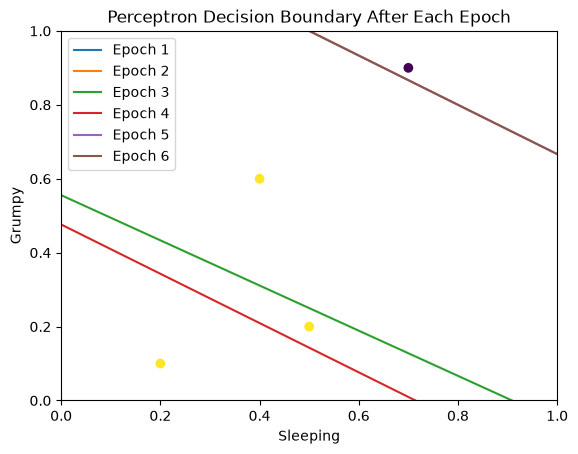


Final weights: [ 2.  -1.  -1.5]


In [90]:
weights = np.zeros(3)

learning_rate = 1
max_epochs = 10

for epoch in range(max_epochs):

    errors = 0

    print(f"\n===== Epoch {epoch + 1} =====")

    for i in range(len(X_bias)):

        x = X_bias[i]
        target = y[i]

        z = np.dot(weights, x)
        prediction = activation(z)

        if prediction != target:

            update = learning_rate * (target - prediction) * x

            weights += update

            errors += 1

            print(
                f"Instance {i + 1}: WRONG → "
                f"weights = {weights}"
            )

        else:

            print(
                f"Instance {i + 1}: CORRECT"
            )

    # ---------- SMALL EPOCH SUMMARY ----------
    print("\n--- Epoch Summary ---")
    print(f"Errors: {errors}")
    print(f"Weights: {weights}")

    # ---------- DECISION BOUNDARY ----------
    w0, w1, w2 = weights

    x_values = np.linspace(0, 1, 100)

    if w2 != 0:
        y_values = -(w0 + w1 * x_values) / w2

        plt.plot(
            x_values,
            y_values,
            label=f"Epoch {epoch + 1}"
        )

    # ---------- CHECK CONVERGENCE ----------
    if errors == 0:
        print("CONVERGED!")
        break


# ---------- PLOT DATA ----------
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    marker="o"
)

plt.xlabel("Sleeping")
plt.ylabel("Grumpy")
plt.title("Perceptron Decision Boundary After Each Epoch")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.legend()
plt.show()

print("\nFinal weights:", weights)

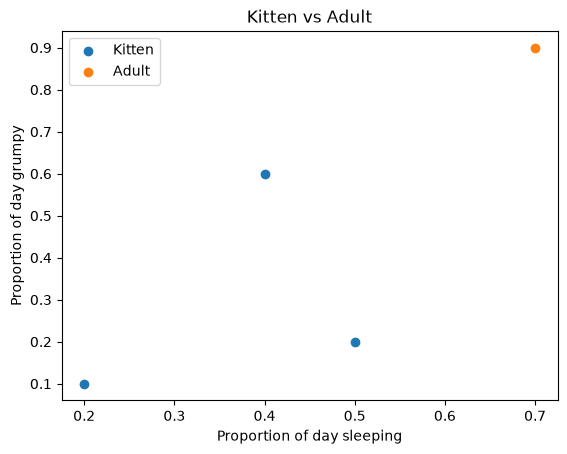

In [91]:
# visualize the traning data
import matplotlib.pyplot as plt

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Kitten"
)

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Adult"
)

plt.xlabel("Proportion of day sleeping")
plt.ylabel("Proportion of day grumpy")
plt.title("Kitten vs Adult")
plt.legend()
plt.show()

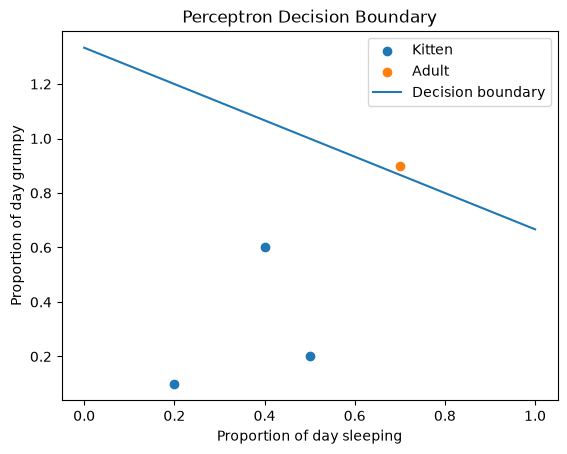

In [92]:
#plot final decision boundary
x_values = np.linspace(0, 1, 100)

y_values = -(weights[0] + weights[1] * x_values) / weights[2]

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Kitten"
)

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Adult"
)

plt.plot(
    x_values,
    y_values,
    label="Decision boundary"
)

plt.xlabel("Proportion of day sleeping")
plt.ylabel("Proportion of day grumpy")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.show()

In [93]:
#useing Scikit-learn
from sklearn.linear_model import Perceptron

model = Perceptron(
    max_iter=10,
    eta0=1,
    random_state=42
)

model.fit(X, y)

,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",10
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


In [94]:
#make predictions
predictions = model.predict(X)

print("Actual:", y)
print("Predicted:", predictions)

Actual: [1 1 1 0]
Predicted: [1 1 1 0]


In [95]:
#look learned parameters
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [[-0.3 -0.9]]
Bias: [1.]


              Training example
                     │
                     ▼
             [x₁, x₂, ...]
                     │
                     ▼
             Multiply by weights
                     │
                     ▼
             Weighted sum + bias
                     │
                     ▼
             Heaviside function
                     │
                     ▼
                Prediction
                     │
                     ▼
          Compare with true class
                     │
              ┌──────┴──────┐
              │             │
           Correct       Incorrect
              │             │
          No update      Update weights
              │             │
              └──────┬──────┘
                     ▼
               Next instance
                     │
                     ▼
                  Epoch
                     │
                     ▼
             Repeat until:
          zero errors OR
          max epochs reached

### Whole Practical in one picture 
DATA
 ↓
[1, 0.2, 0.1] → target 1
[1, 0.4, 0.6] → target 1
[1, 0.5, 0.2] → target 1
[1, 0.7, 0.9] → target 0

 ↓

START
weights = [0, 0, 0]

 ↓

Take one instance

 ↓

z = weights · inputs

 ↓

Heaviside(z)

 ↓

Prediction

 ↓

Compare with target

       ┌──────────────┐
       │              │
    Correct       Incorrect
       │              │
       ↓              ↓
   No update     Update weights
                      │
                      ↓
               next instance

 ↓

All instances finished?

 ↓

One epoch completed

 ↓

Errors = 0?
   │
 YES ──→ CONVERGED
   │
 NO
   ↓
Next epoch